# Tokamak Power Balance with Radiation Decomposition

이 노트북은 두 가지를 재현합니다.

1. `Aurora` cooling curve 기반 Radiation 손실 채널 비교 (Te 스캔)
2. ODS 기반 시간축 tokamak power balance 플롯 (입력/손실/복사 분해)

참고 로직:
- `Aurora/analysis/carbon_oxygen_cooling_analysis.py`
- `Aurora/analysis/vest_loss_channel_comparison.py`
- `vaft.omas.compute_power_balance`
- `vaft.plot.time_power_balance`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants

import vaft

# plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "legend.fontsize": 18,
})

In [2]:
# ------------------------------
# User configuration
# ------------------------------
SHOT = None  # 예: 45538. None이면 core_profile shot 중 첫 번째 사용
DIRECTORY = "public"

TE_MIN_EV = 1.0
TE_MAX_EV = 300.0
N_TE = 800
NE_M3 = 1.0e19
BT_T = 0.18
Z_EFF = 2.0

# n_Z = f_Z * n_e
RADIATION_FRACTIONS = {
    "H": 1.0,
    "C": 0.01,
    "O": 0.01,
}

# compute_power_balance에서 사용할 line-radiation 종/농도
LINE_SPECIES = ["C", "O"]
IMPURITY_FRACTIONS = {"C": 0.01, "O": 0.01}


def choose_default_shot() -> int:
    status_df = vaft.database.exist_ts_file()
    if status_df is None or status_df.empty:
        raise RuntimeError("No processed TS shot table available. Set SHOT manually.")
    core_profile_shots = status_df[status_df["Status"] == "core_profile"]["Shot Number"].astype(int)
    if core_profile_shots.empty:
        raise RuntimeError("No core_profile shots found. Set SHOT manually.")
    return int(core_profile_shots.iloc[0])


if SHOT is None:
    SHOT = choose_default_shot()

ods = vaft.database.ods.load(int(SHOT), directory=DIRECTORY)
print(f"Using shot={SHOT} from directory='{DIRECTORY}'")

Available Thomson Scattering Shots:

|   Index |   Shot Number | Last Processed             | Status       |
|---------|---------------|----------------------------|--------------|
|       1 |         22027 | 2023-02-02T23:24:20        | invalid      |
|       2 |         39513 | 2024-08-06T11:18:45.556514 | thomson_only |
|       3 |         39515 | 2024-08-06T11:19:39.748631 | thomson_only |
|       4 |         39906 | 2024-08-06T11:20:05.668157 | core_profile |
|       5 |         39915 | 2024-05-14T16:42:35.439538 | invalid      |
|       6 |         39916 | 2024-07-08T20:11:09.953256 | core_profile |
|       7 |         39917 | 2023-07-05T20:47:14        | core_profile |
|       8 |         40282 | 2024-08-06T11:20:28.826835 | core_profile |
|       9 |         40323 | 2023-07-28T16:04:09        | thomson_only |
|      10 |         40324 | 2023-07-28T16:05:23        | thomson_only |
|      11 |         40325 | 2023-07-28T16:06:39        | core_profile |
|      12 |         40326 |

## 1) Radiation Loss Channels on a Common Basis (Te scan)

`vest_loss_channel_comparison.py` 로직과 같이,

- cooling coefficient: $L_Z(T_e)$
- volumetric radiation: $p_Z(T_e) = n_e n_Z L_Z(T_e)$

을 사용하여 H/C/O 복사와 bremsstrahlung/cyclotron scaling을 같은 단위 `W/m^3`로 비교합니다.

In [3]:
import aurora


def build_te_grid(te_min_ev: float, te_max_ev: float, n_te: int) -> np.ndarray:
    return np.logspace(np.log10(te_min_ev), np.log10(te_max_ev), n_te)


def get_total_cooling_coefficients(symbol: str, te_ev: np.ndarray, ne_m3: float) -> np.ndarray:
    ne_cm3 = np.full_like(te_ev, ne_m3 * 1.0e-6)
    line_total, cont_total = aurora.radiation.get_cooling_factors(
        imp=symbol,
        ne_cm3=ne_cm3,
        Te_eV=te_ev,
        plot=False,
        ion_resolved=False,
    )
    return np.asarray(line_total, dtype=float) + np.asarray(cont_total, dtype=float)


def radiation_power_density(lz_w_m3: np.ndarray, ne_m3: float, fraction: float) -> np.ndarray:
    n_species = max(float(fraction), 0.0) * ne_m3
    return ne_m3 * n_species * lz_w_m3


def bremsstrahlung_power_density(te_ev: np.ndarray, ne_m3: float, z_eff: float) -> np.ndarray:
    return 1.69e-38 * z_eff * ne_m3**2 * np.sqrt(te_ev)


def cyclotron_scaling_power_density(te_ev: np.ndarray, ne_m3: float, bt_t: float) -> np.ndarray:
    coeff = constants.e**4 / (3.0 * np.pi * constants.epsilon_0 * constants.m_e**3 * constants.c**3)
    return coeff * ne_m3 * bt_t**2 * (te_ev * constants.e)


te_ev = build_te_grid(TE_MIN_EV, TE_MAX_EV, N_TE)

lz = {
    "H": get_total_cooling_coefficients("H", te_ev, NE_M3),
    "C": get_total_cooling_coefficients("C", te_ev, NE_M3),
    "O": get_total_cooling_coefficients("O", te_ev, NE_M3),
}

channels_w_m3 = {
    "Hydrogen radiation": radiation_power_density(lz["H"], NE_M3, RADIATION_FRACTIONS["H"]),
    "Carbon radiation": radiation_power_density(lz["C"], NE_M3, RADIATION_FRACTIONS["C"]),
    "Oxygen radiation": radiation_power_density(lz["O"], NE_M3, RADIATION_FRACTIONS["O"]),
    "Bremsstrahlung estimate": bremsstrahlung_power_density(te_ev, NE_M3, Z_EFF),
    "Cyclotron/synchrotron scaling": cyclotron_scaling_power_density(te_ev, NE_M3, BT_T),
}

p_total = np.zeros_like(te_ev)
for v in channels_w_m3.values():
    p_total += np.asarray(v, dtype=float)

channel_df = pd.DataFrame({"Te_eV": te_ev, **channels_w_m3, "Total": p_total})
channel_df.head()

,Te_eV,Hydrogen radiation,Carbon radiation,Oxygen radiation,Bremsstrahlung estimate,Cyclotron/synchrotron scaling,Total
0,1.000000,211.792733,121.351047,11.382674,3.380000,0.020126,347.926580
1,1.007164,224.148954,126.696400,11.785198,3.392086,0.020270,366.042907
2,1.014380,237.155392,132.124736,12.192929,3.404215,0.020415,384.897687
3,1.021647,250.835472,137.745349,12.613459,3.416387,0.020561,404.631228
4,1.028966,265.211766,143.561802,13.046984,3.428603,0.020709,425.269864


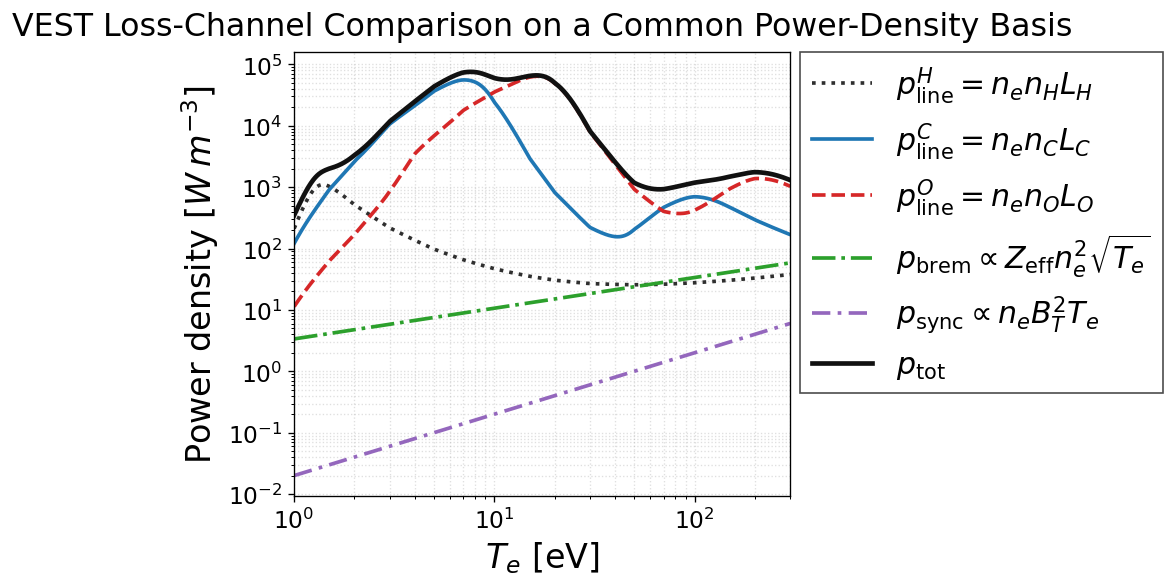

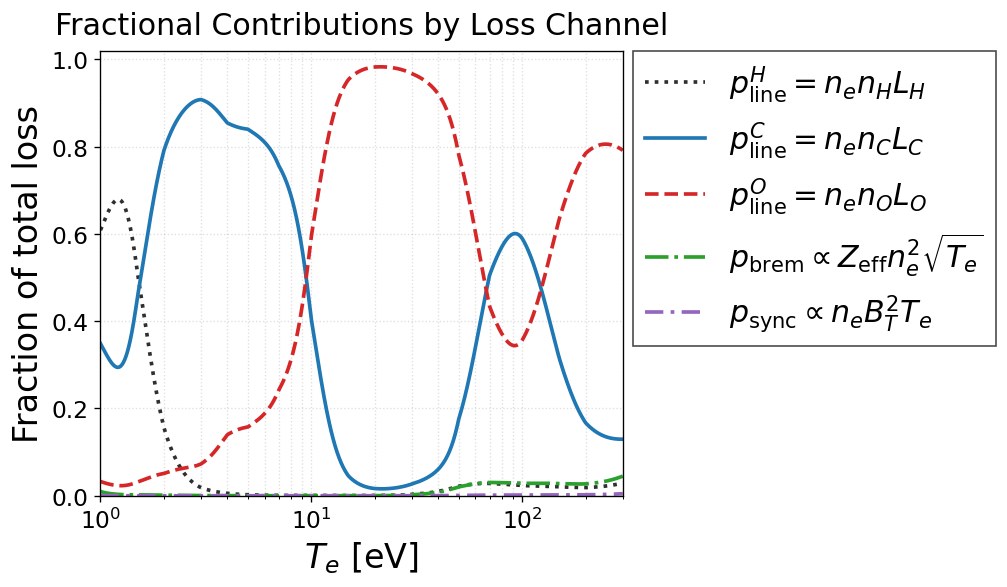

In [4]:
styles = {
    "Hydrogen radiation": {"color": "#2f2f2f", "ls": ":"},
    "Carbon radiation": {"color": "#1f77b4", "ls": "-"},
    "Oxygen radiation": {"color": "#d62728", "ls": "--"},
    "Bremsstrahlung estimate": {"color": "#2ca02c", "ls": "-."},
    "Cyclotron/synchrotron scaling": {"color": "#9467bd", "ls": (0, (5, 2, 1, 2))},
    "Total": {"color": "#111111", "ls": "-"},
}

legend_labels = {
    "Hydrogen radiation": r"$p_{\mathrm{line}}^{H}=n_e n_H L_H$",
    "Carbon radiation": r"$p_{\mathrm{line}}^{C}=n_e n_C L_C$",
    "Oxygen radiation": r"$p_{\mathrm{line}}^{O}=n_e n_O L_O$",
    "Bremsstrahlung estimate": r"$p_{\mathrm{brem}}\propto Z_{\mathrm{eff}}n_e^2\sqrt{T_e}$",
    "Cyclotron/synchrotron scaling": r"$p_{\mathrm{sync}}\propto n_e B_T^2 T_e$",
    "Total": r"$p_{\mathrm{tot}}$",
}

channel_order = [
    "Hydrogen radiation",
    "Carbon radiation",
    "Oxygen radiation",
    "Bremsstrahlung estimate",
    "Cyclotron/synchrotron scaling",
]

legend_kwargs = {
    "frameon": True,
    "fancybox": False,
    "framealpha": 1.0,
    "facecolor": "white",
    "edgecolor": "0.3",
}

# (a) 채널별 파워밀도: 독립 Figure
fig, ax = plt.subplots(figsize=(11, 5))
for name in channel_order:
    ax.loglog(
        te_ev,
        channels_w_m3[name],
        label=legend_labels[name],
        color=styles[name]["color"],
        linestyle=styles[name]["ls"],
        linewidth=2.2,
    )
ax.loglog(
    te_ev,
    p_total,
    label=legend_labels["Total"],
    color=styles["Total"]["color"],
    linestyle=styles["Total"]["ls"],
    linewidth=2.8,
)
ax.set_xlim(1.0, 3.0e2)
ax.set_xlabel(r"$T_e$ [eV]")
ax.set_ylabel(r"Power density [$W\,m^{-3}$]")
ax.set_title("VEST Loss-Channel Comparison on a Common Power-Density Basis", fontsize=19, pad=10)
ax.tick_params(axis="x", which="both", labelsize=14)
ax.tick_params(axis="y", which="both", labelsize=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, **legend_kwargs)
ax.grid(True, which="both", alpha=0.4, linestyle=":")
fig.tight_layout(rect=(0.0, 0.0, 0.78, 1.0))
plt.show()

# (b) 분율: 독립 Figure
fig, ax = plt.subplots(figsize=(11, 5))
for name in channel_order:
    frac = np.divide(channels_w_m3[name], p_total, out=np.zeros_like(p_total), where=p_total > 0.0)
    ax.semilogx(
        te_ev,
        frac,
        label=legend_labels[name],
        color=styles[name]["color"],
        linestyle=styles[name]["ls"],
        linewidth=2.2,
    )
ax.set_xlim(1.0, 3.0e2)
ax.set_ylim(0.0, 1.02)
ax.set_xlabel(r"$T_e$ [eV]")
ax.set_ylabel("Fraction of total loss")
ax.set_title("Fractional Contributions by Loss Channel", fontsize=18, pad=10)
ax.tick_params(axis="x", which="both", labelsize=14)
ax.tick_params(axis="y", which="both", labelsize=14)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, **legend_kwargs)
ax.grid(True, which="both", alpha=0.4, linestyle=":")
fig.tight_layout(rect=(0.0, 0.0, 0.78, 1.0))
plt.show()

## 2) Time-domain Tokamak Power Balance (ODS 기반)

이 파트는 `vaft.omas.compute_power_balance` 결과를 바탕으로,

- 입력/가열 파워 (`P_heat`, `P_ohm`)
- 손실 분해 (`P_loss`, `P_trans`, `P_rad`)
- Radiation 분해 (`P_rad`, `P_line`, `P_Br`, `P_sync`)

를 시간축에서 재현합니다.

여기서 총복사는
`P_rad = P_rad_line + P_sync + P_Br`
로 정의됩니다.

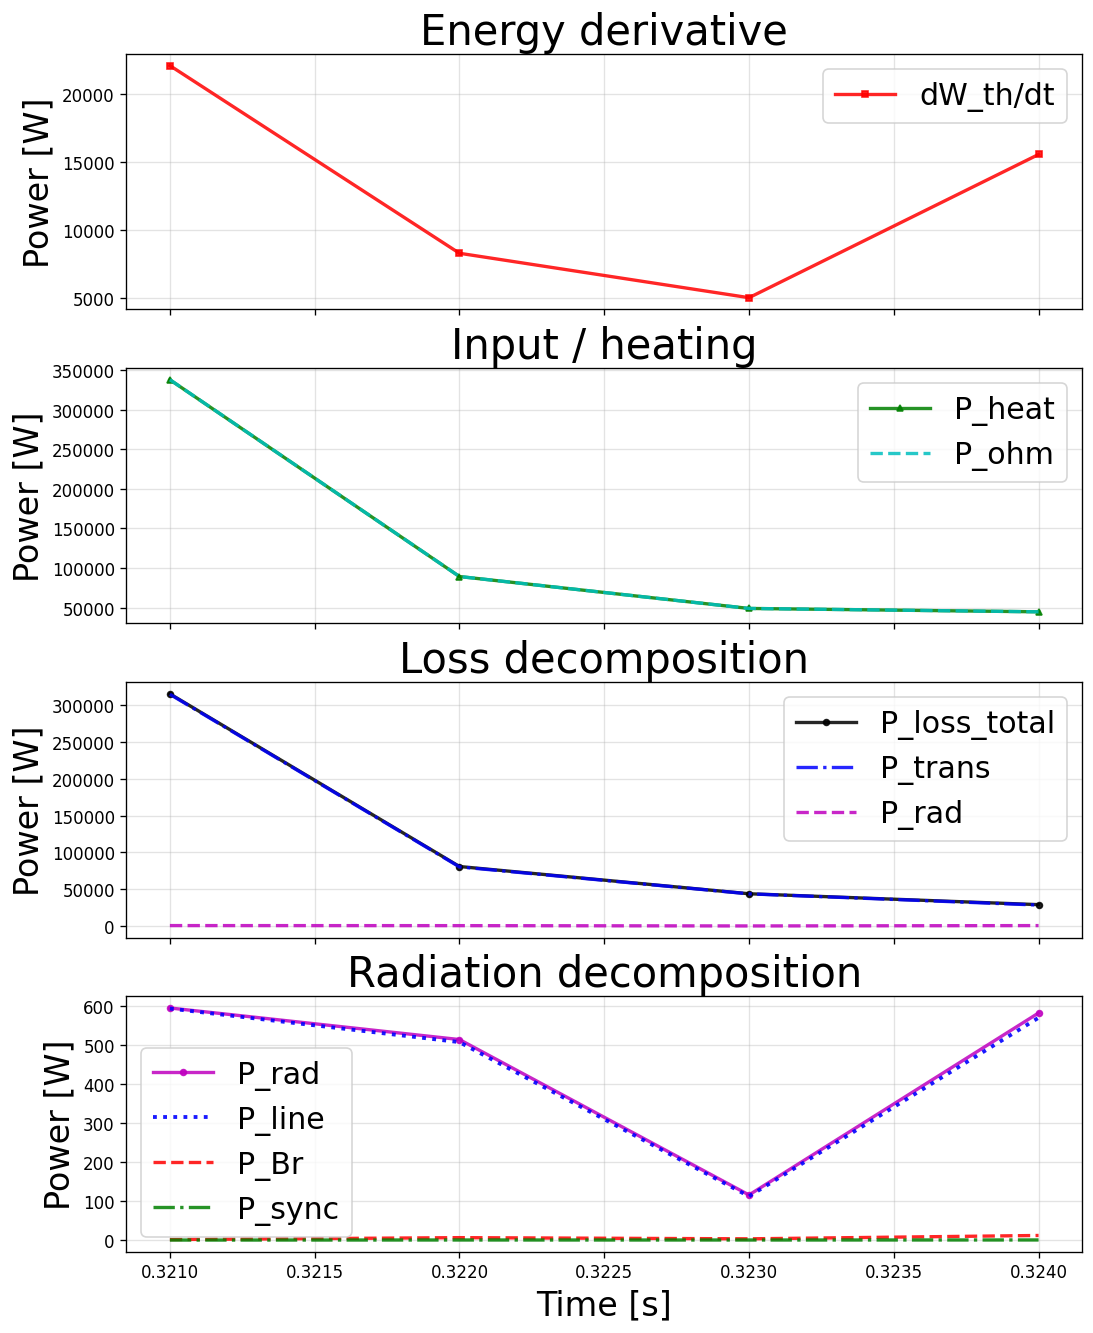

In [5]:
power_balance = vaft.omas.compute_power_balance(
    ods,
    include_line_radiation=True,
    line_radiation_species=LINE_SPECIES,
    impurity_fractions=IMPURITY_FRACTIONS,
    Z_eff=Z_EFF,
)

t = np.asarray(power_balance["time"], dtype=float)
P_heat = np.asarray(power_balance.get("P_heat", np.zeros_like(t)), dtype=float)
P_ohm = np.asarray(power_balance.get("P_ohm_diss", power_balance.get("P_ohm_flux", np.zeros_like(t))), dtype=float)
P_line = np.asarray(power_balance.get("P_rad_line", np.zeros_like(t)), dtype=float)
P_Br = np.asarray(power_balance.get("P_Br", np.zeros_like(t)), dtype=float)
P_sync = np.asarray(power_balance.get("P_sync", np.zeros_like(t)), dtype=float)
P_rad = np.asarray(power_balance.get("P_rad", P_line + P_sync + P_Br), dtype=float)
P_trans = np.asarray(power_balance.get("P_trans", power_balance.get("P_loss", np.zeros_like(t))), dtype=float)
P_loss_total = np.asarray(power_balance.get("P_loss_total", P_rad + P_trans), dtype=float)
dWdt = np.asarray(power_balance.get("dWdt", np.zeros_like(t)), dtype=float)

fig, axes = plt.subplots(4, 1, figsize=(9, 11), sharex=True, constrained_layout=True)

axes[0].plot(t, dWdt, "r-s", linewidth=2.0, markersize=3.5, alpha=0.85, label="dW_th/dt")
axes[0].set_ylabel("Power [W]")
axes[0].set_title("Energy derivative")
axes[0].legend()
axes[0].grid(True, alpha=0.35)

axes[1].plot(t, P_heat, "g-^", linewidth=2.0, markersize=3.5, alpha=0.85, label="P_heat")
axes[1].plot(t, P_ohm, "c--", linewidth=2.0, alpha=0.85, label="P_ohm")
axes[1].set_ylabel("Power [W]")
axes[1].set_title("Input / heating")
axes[1].legend()
axes[1].grid(True, alpha=0.35)

axes[2].plot(t, P_loss_total, "k-o", linewidth=2.0, markersize=3.5, alpha=0.85, label="P_loss_total")
axes[2].plot(t, P_trans, "b-.", linewidth=2.0, alpha=0.85, label="P_trans")
axes[2].plot(t, P_rad, "m--", linewidth=2.0, alpha=0.85, label="P_rad")
axes[2].set_ylabel("Power [W]")
axes[2].set_title("Loss decomposition")
axes[2].legend()
axes[2].grid(True, alpha=0.35)

axes[3].plot(t, P_rad, "m-o", linewidth=2.0, markersize=3.5, alpha=0.85, label="P_rad")
axes[3].plot(t, P_line, "b:", linewidth=2.3, alpha=0.9, label="P_line")
axes[3].plot(t, P_Br, "r--", linewidth=2.0, alpha=0.85, label="P_Br")
axes[3].plot(t, P_sync, "g-.", linewidth=2.0, alpha=0.85, label="P_sync")
axes[3].set_xlabel("Time [s]")
axes[3].set_ylabel("Power [W]")
axes[3].set_title("Radiation decomposition")
axes[3].legend()
axes[3].grid(True, alpha=0.35)

plt.show()

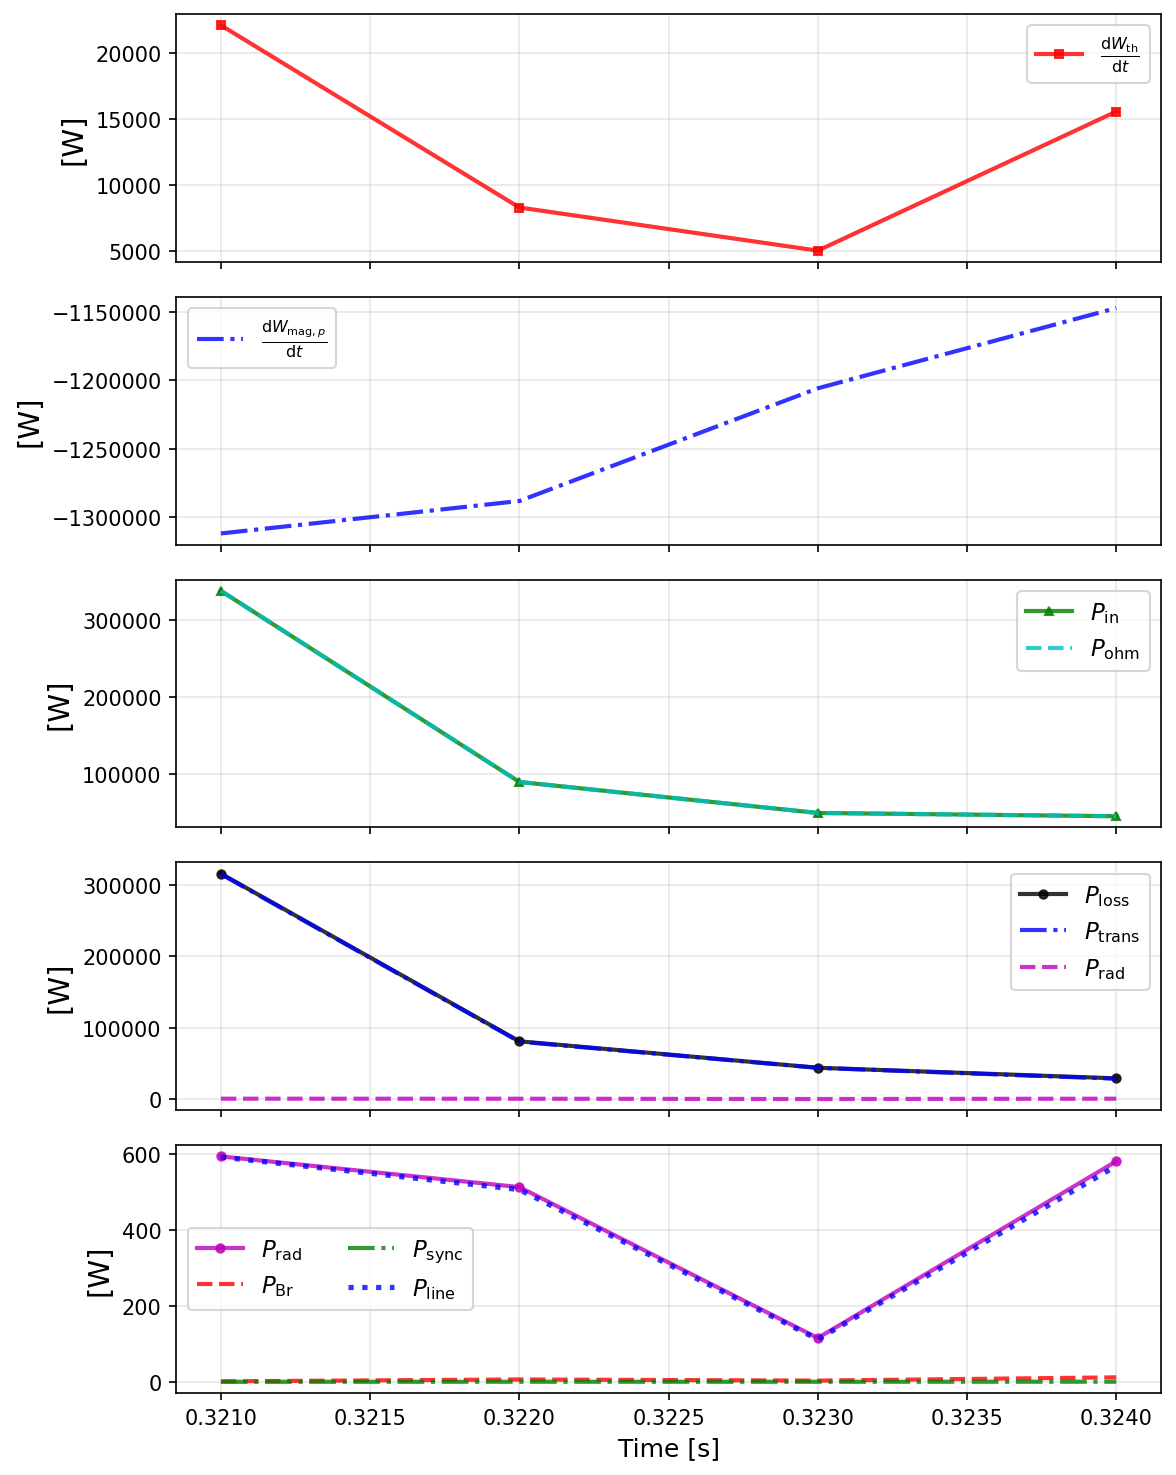

In [6]:
# 동일 데이터를 vaft 내장 플롯 함수로도 확인 (교차 검증)
fig_ref = vaft.plot.time_power_balance(ods, figsize=(8, 10))
plt.show()